## Business Problem

Natural disasters pose varying degrees of humanitarian and economic challenges across regions worldwide.  They differ in degrees of severity, frequency, and type depending on the location.  Therefore, governments, international relief agencies, and non-governmental organizations (NGOs) can benefit from a data-driven approach to disaster analysis.  Such support could aid in decision-making under uncertainty and improve preparedness, resource allocation, and response strategies.  This project aims to develop predictive models that serve as supportive proactive tools that can be used to estimate disaster severity and expected human and economic losses by using historical global disaster data from 2018 to 2024. 

## Background and Context:

Global disaster-related losses have increased substantially over recent decades, placing growing strain on humanitarian systems, public infrastructure, and national economies. Direct disaster losses averaged approximately 70–80 billion annually between 1970 and 2000, but rose to an estimated 180–200 billion per year between 2001 and 2022. When indirect, cascading, and ecosystem-related impacts are considered, total global disaster costs exceeded $2.3 trillion annually by 2023 (UNDRR, 2025). These trends highlight the growing need for improved risk-informed decision-making tools that support preparedness rather than reactive response.

The economic and humanitarian consequences of disasters disproportionately affect least developed countries (LDCs) and small island developing states (SIDS), where single events can consume a substantial share of national GDP and reinforce cycles of vulnerability and humanitarian dependency. The Global Assessment Report on Disaster Risk Reduction 2025 emphasizes that without proactive disaster risk reduction strategies, these cycles will continue to undermine long-term development and economic stability (UNDRR, 2025). Prior research demonstrates that disaster impacts are not solely determined by hazard intensity, but are strongly influenced by social vulnerability, geographic exposure, and economic conditions, underscoring the need for predictive, impact-focused approaches to disaster analysis (Cutter & Emrich, 2006).

## The Dataset
The dataset comes from Kaggle: "Global Disasters Response Analysis" by Zuair Dhuddi. 

Link: https://www.kaggle.com/datasets/zubairdhuddi/global-daset?utm_source=chatgpt.com

## Data Explanation and Preparation

The analysis uses the Global Disaster Response Dataset (2018–2024), obtained from Kaggle, containing 50,000 recorded disaster events across 20 countries and 10 disaster types. Key variables include disaster type, geographic location (latitude and longitude), severity index, casualty counts, estimated economic losses (USD), response time, aid amount, and response efficiency score.

Initial data quality checks confirmed that no missing values were present across all variables, allowing the full dataset to be retained for analysis. Distributional analysis revealed that economic loss values were highly right-skewed, with a small number of extreme events substantially increasing the mean relative to the median. This pattern is typical of disaster data, where most events incur moderate losses while a few catastrophic disasters account for disproportionately high costs. To stabilize variance and improve model performance, a logarithmic transformation (log1p) was applied to economic loss prior to modeling.

In contrast, the severity index exhibited a roughly bell-shaped distribution centered around mid-range values, with fewer observations at the extreme low and high ends. This distribution is suitable for regression-based modeling, though robust error metrics were later used to account for potential outliers.

Categorical variables, including disaster type and country, were examined for sparsity, rare categories, and inconsistencies. Disaster types were evenly distributed, with approximately 5,000 observations per category, and country-level observations ranged between roughly 2,400 and 2,600 records per country. No dominant or rare categories were identified, reducing the risk of sparse encoding issues. All categorical variables were confirmed to be consistently labeled.

Predictor variables were selected to avoid data leakage and reflect information observable prior to or during disaster response. These include response time, aid allocation, response efficiency, geographic location, disaster type, and country. Collectively, these features capture operational capacity, geographic exposure, and hazard-specific characteristics while excluding post-outcome indicators. The final prepared dataset was deemed suitable for predictive modeling, with sufficient sample size and balanced categorical distributions.

## Data Preparation

In [1]:
# import necessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_path = 'global_disaster_response_2018_2024 (1).csv'

df = pd.read_csv(file_path)

df.head()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,2021-01-31,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,2018-12-23,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,2020-08-10,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,2022-09-15,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,2022-09-28,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       50000 non-null  object 
 1   country                    50000 non-null  object 
 2   disaster_type              50000 non-null  object 
 3   severity_index             50000 non-null  float64
 4   casualties                 50000 non-null  int64  
 5   economic_loss_usd          50000 non-null  float64
 6   response_time_hours        50000 non-null  float64
 7   aid_amount_usd             50000 non-null  float64
 8   response_efficiency_score  50000 non-null  float64
 9   recovery_days              50000 non-null  int64  
 10  latitude                   50000 non-null  float64
 11  longitude                  50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


In [4]:
df.describe(include='all')

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
count,50000,50000,50000,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000
unique,2557,20,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2023-08-29,Brazil,Landslide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,36,2591,5130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.015769,100.591140,5.068593e+06,12.183027,2.500003e+05,87.574025,49.682560,0.231205,0.089889
std,NaN,NaN,NaN,1.942843,65.052064,3.268541e+06,9.259081,1.432275e+05,10.188961,20.098944,34.759662,98.380208
min,NaN,NaN,NaN,1.000000,0.000000,5.273900e+02,1.000000,1.660000e+01,29.750000,2.000000,-59.994000,-169.998000
25%,NaN,NaN,NaN,3.660000,51.000000,2.585513e+06,6.270000,1.429663e+05,83.060000,36.000000,-29.848250,-85.551750
50%,NaN,NaN,NaN,4.990000,91.000000,4.548351e+06,10.510000,2.305365e+05,89.180000,49.000000,0.267500,0.390500
75%,NaN,NaN,NaN,6.340000,138.000000,6.950615e+06,15.450000,3.352259e+05,94.700000,63.000000,30.488250,85.665000


In [5]:
df.isna().sum()

date                         0
country                      0
disaster_type                0
severity_index               0
casualties                   0
economic_loss_usd            0
response_time_hours          0
aid_amount_usd               0
response_efficiency_score    0
recovery_days                0
latitude                     0
longitude                    0
dtype: int64

In [6]:
df['disaster_type'].unique()

array(['Earthquake', 'Extreme Heat', 'Hurricane', 'Wildfire', 'Flood',
       'Storm Surge', 'Drought', 'Tornado', 'Landslide',
       'Volcanic Eruption'], dtype=object)

In [7]:
df['disaster_type'].value_counts()

disaster_type
Landslide            5130
Earthquake           5068
Flood                5039
Hurricane            5002
Extreme Heat         5001
Storm Surge          4988
Volcanic Eruption    4983
Wildfire             4954
Tornado              4939
Drought              4896
Name: count, dtype: int64

In [8]:
# explore distriubtion
df['economic_loss_usd'].describe()

count    5.000000e+04
mean     5.068593e+06
std      3.268541e+06
min      5.273900e+02
25%      2.585513e+06
50%      4.548351e+06
75%      6.950615e+06
max      2.445624e+07
Name: economic_loss_usd, dtype: float64

Gained information:
1. Mean > Median, indicating a right skew
2. Range: large spread (min is 500 and max is 24.4M), indicating extreme events are pulling the distriubtion upward
This pattern is expected in disaster data with most events moderate, while few are catastrophic.
3. Threrefore log-transform economic loss

Text(0.5, 1.0, 'Log-Transformed Economic Loss Distribution')

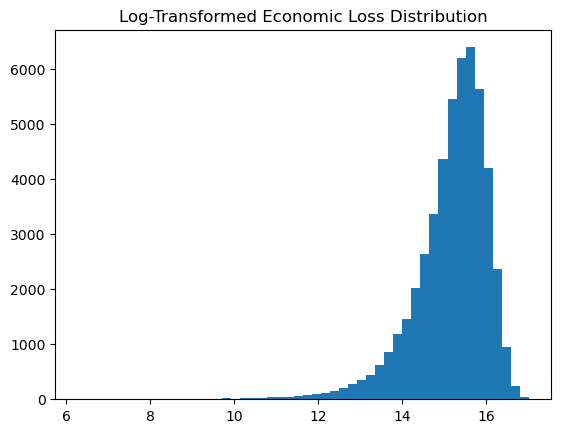

In [9]:
plt.hist(np.log1p(df['economic_loss_usd']), bins=50)
plt.title('Log-Transformed Economic Loss Distribution')

In [10]:
# log transform economic loss
df['log_economic_loss'] = np.log1p(df['economic_loss_usd'])

<Axes: >

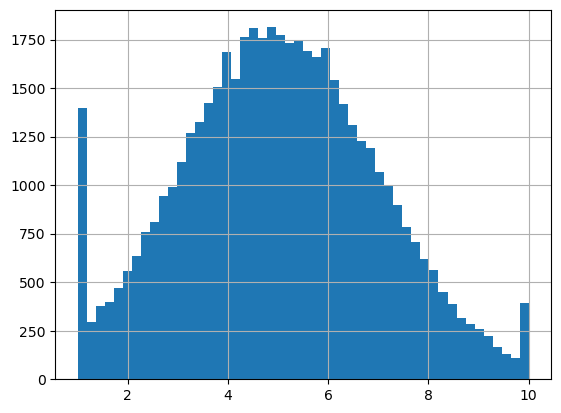

In [11]:
df['severity_index'].hist(bins=50)

Observations from the severity_index histogram:

Roughly bell-shaped in the middle:

Most values cluster around 4–6.

This looks somewhat normal, which is good for modeling.

Spikes at the edges (around 1–2 and 10):

You have some outliers or extreme cases.

Possibly very mild or extremely severe disasters are less frequent but present.

Implications:

You might scale the severity_index for some algorithms (like linear regression or neural nets) for better performance.

Tree-based models (Random Forest, XGBoost) don’t require scaling, but scaling helps if you want to try models like Ridge/Lasso regression.

Extreme values might be influential, so consider evaluating the model with robust metrics like MAE or RMSE.`m

## Analyze categorical variabless

In [12]:
# check categorical variables for disaster_type and country

# Disaster type counts
print(df['disaster_type'].value_counts())

# Country counts
print(df['country'].value_counts())

disaster_type
Landslide            5130
Earthquake           5068
Flood                5039
Hurricane            5002
Extreme Heat         5001
Storm Surge          4988
Volcanic Eruption    4983
Wildfire             4954
Tornado              4939
Drought              4896
Name: count, dtype: int64
country
Brazil           2591
Australia        2563
Turkey           2554
Bangladesh       2553
Spain            2543
China            2539
Chile            2529
Nigeria          2528
Germany          2526
India            2509
Greece           2503
Italy            2503
South Africa     2497
Japan            2472
Indonesia        2467
Canada           2438
Philippines      2437
Mexico           2433
United States    2413
France           2402
Name: count, dtype: int64


Analysis of categorical variables showed balanced distributions across disaster types and countries, with no rare categories or dominant classes. As a result, no category consolidation or grouping was necessary prior to encoding.

In [13]:
# Covert date ccolum to date time
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# create new year column
df['year'] = df['date'].dt.year

In [14]:
# verify it worked
df[['date', 'year']].head()

,date,year
0,2021-01-31,2021
1,2018-12-23,2018
2,2020-08-10,2020
3,2022-09-15,2022
4,2022-09-28,2022


## EDA

### analyze by year

In [15]:
df['year'].value_counts().sort_index()

year
2018    7014
2019    7113
2020    7247
2021    7271
2022    7130
2023    7139
2024    7086
Name: count, dtype: int64

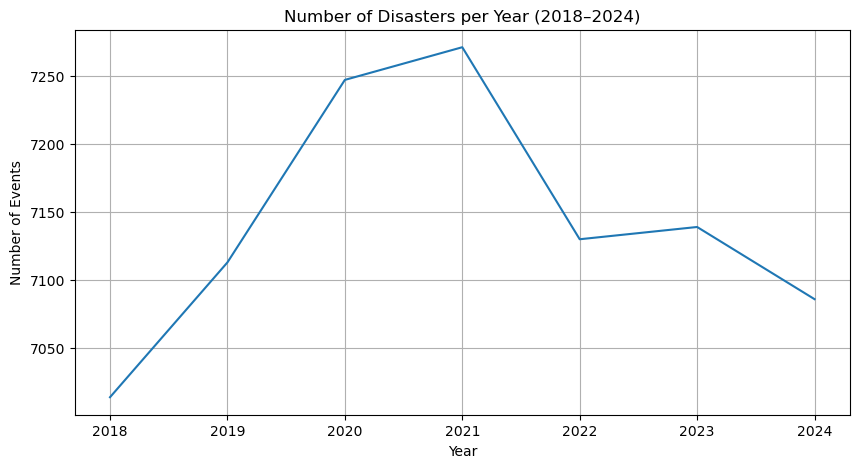

In [16]:
plt.figure(figsize=(10,5))
df['year'].value_counts().sort_index().plot(kind='line')

plt.title('Number of Disasters per Year (2018–2024)')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.grid(True)
plt.show()

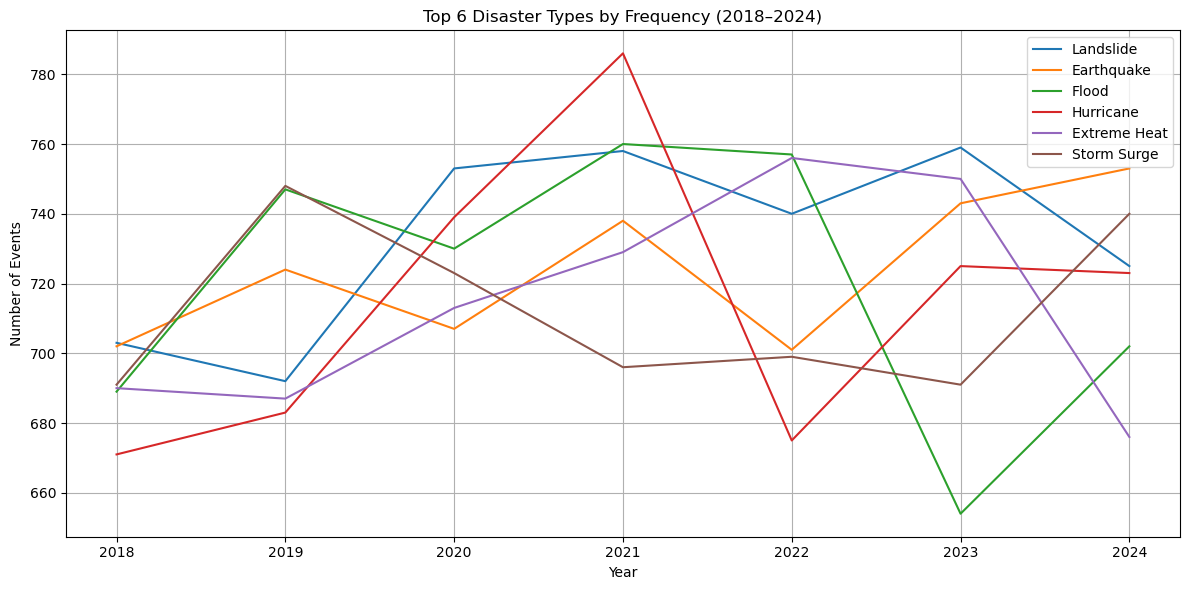

In [17]:
# Analyzing per top 6 disaster type since 2021 - 2024 is showing a decreased amount in number of disasters per year

# Identify top 6 disaster types
top_6 = (
    df['disaster_type']
    .value_counts()
    .head(6)
    .index
)

# Filter dataset
df_top6 = df[df['disaster_type'].isin(top_6)]

# Plot trends
plt.figure(figsize=(12,6))

for d_type in top_6:
    yearly_counts = (
        df_top6[df_top6['disaster_type'] == d_type]
        .groupby('year')
        .size()
    )
    plt.plot(yearly_counts.index, yearly_counts.values, label=d_type)

plt.title('Top 6 Disaster Types by Frequency (2018–2024)')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

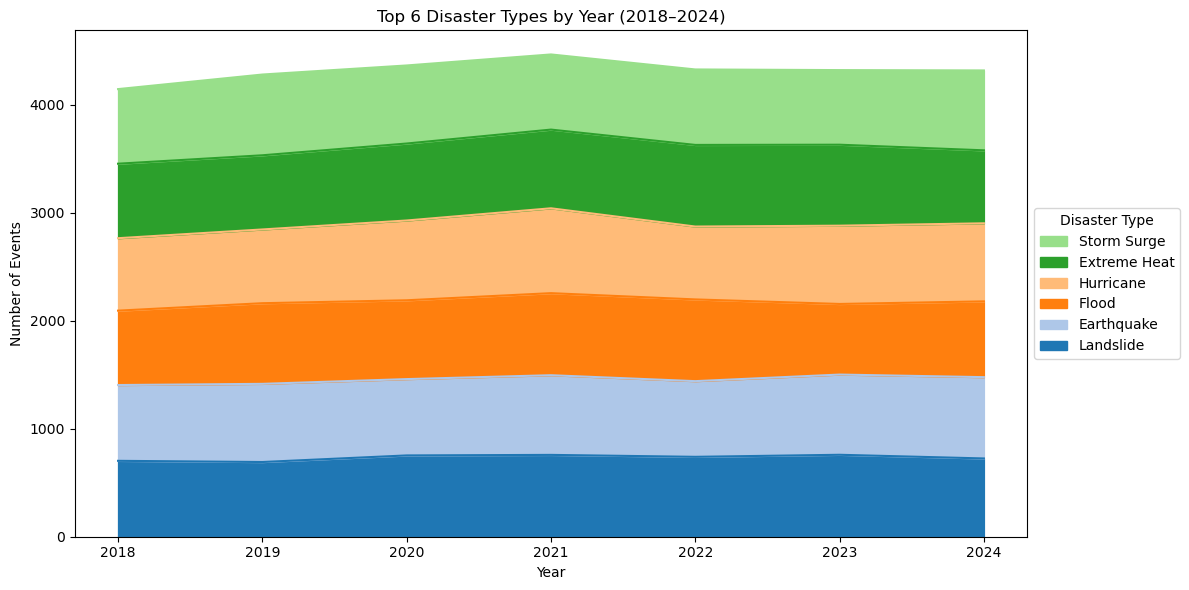

In [18]:
# Get top 6 disaster types
top_6 = df['disaster_type'].value_counts().head(6)

# Order columns: largest to smallest for stacking (bottom → top)
stack_order = top_6.sort_values(ascending=False).index

# Filter dataset for top 6
df_top6 = df[df['disaster_type'].isin(stack_order)]

# Group by year and disaster_type
yearly_counts = df_top6.groupby(['year', 'disaster_type']).size().unstack(fill_value=0)

# Reorder columns for proper stacking
yearly_counts = yearly_counts[stack_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20.colors[:len(stack_order)]
yearly_counts.plot(kind='area', stacked=True, ax=ax, color=colors)

# Title & labels
ax.set_title('Top 6 Disaster Types by Year (2018–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')

# Fix legend: reverse so it matches the stack from bottom → top
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Disaster Type', loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

### analyze by month

In [19]:
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

# Calender order 
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['month_name'].value_counts().reindex(month_order)

month_name
January      4318
February     3854
March        4207
April        4108
May          4195
June         4205
July         4233
August       4252
September    4067
October      4244
November     4124
December     4193
Name: count, dtype: int64

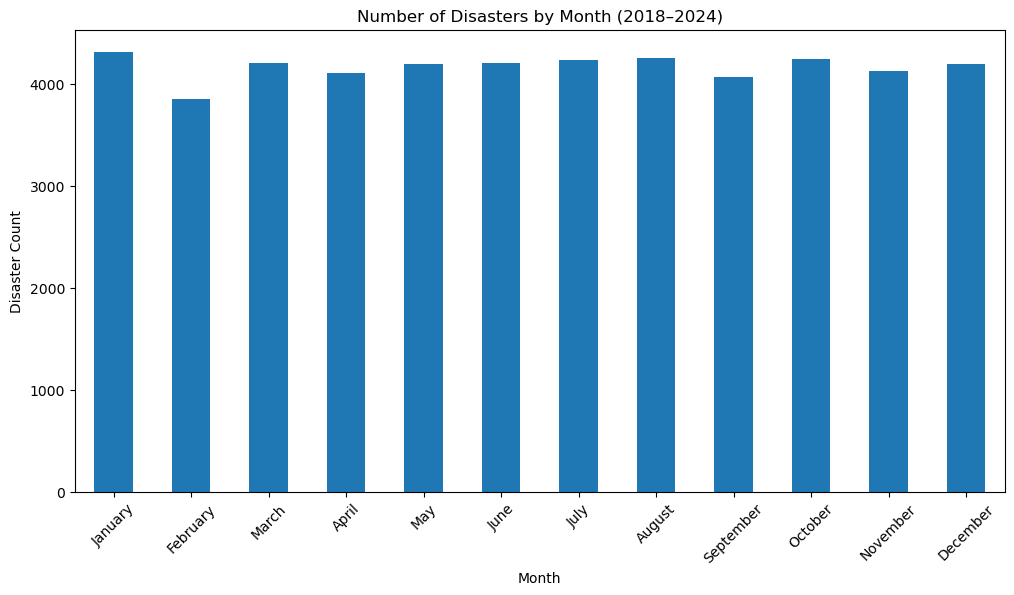

In [20]:
# plot disasters per month

plt.figure(figsize=(12,6))
df['month_name'].value_counts().reindex(month_order).plot(kind='bar')

plt.title('Number of Disasters by Month (2018–2024)')
plt.xlabel('Month')
plt.ylabel('Disaster Count')
plt.xticks(rotation=45)
plt.show()

#### Create season column
Winter = December–February

Spring = March–May

Summer = June–August

Fall = September–November

In [21]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

In [22]:
df['season'].value_counts()

season
Summer    12690
Spring    12510
Fall      12435
Winter    12365
Name: count, dtype: int64

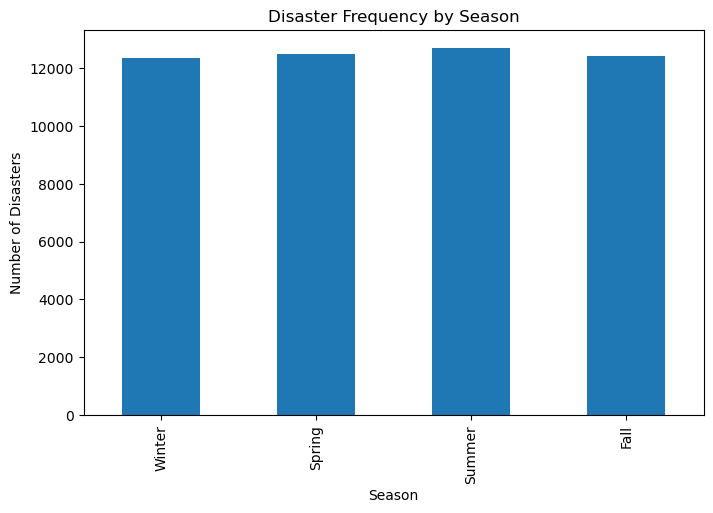

In [23]:
plt.figure(figsize=(8,5))
df['season'].value_counts().reindex(['Winter','Spring','Summer','Fall']).plot(kind='bar')

plt.title('Disaster Frequency by Season')
plt.xlabel('Season')
plt.ylabel('Number of Disasters')
plt.show()

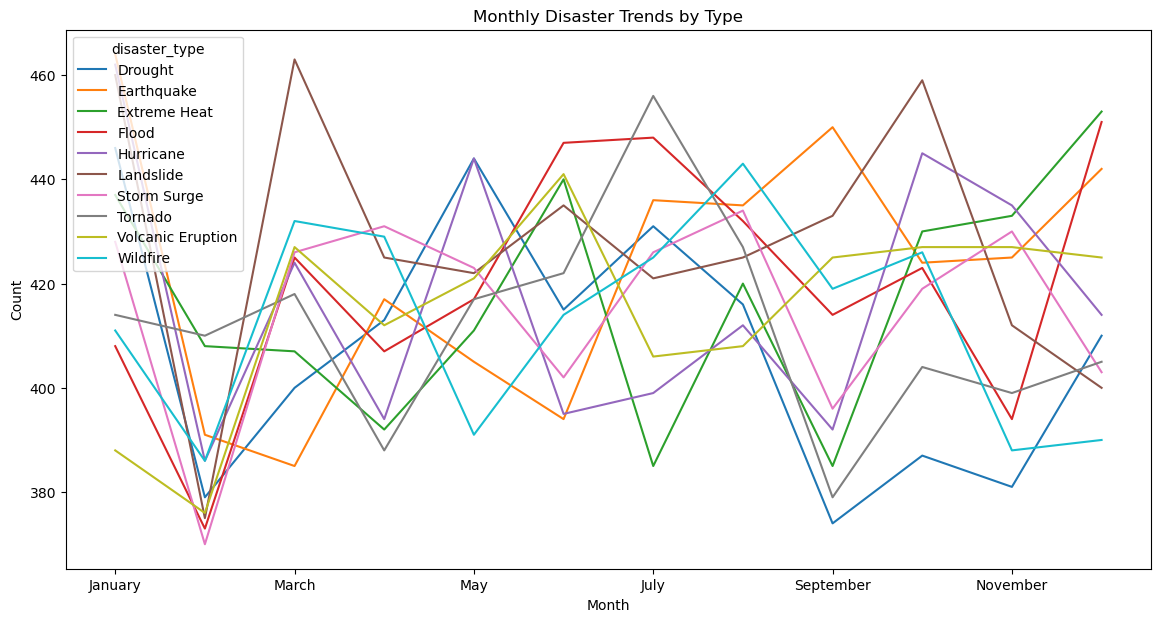

In [24]:
df.groupby(['month_name','disaster_type']).size().unstack().reindex(month_order).plot(figsize=(14,7))
plt.title('Monthly Disaster Trends by Type')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

## Predictive Model

### Information

prediction targets:
severity_index (continous)
economoic_loss (continous)

Since targets are continous, linear regression, random forest regressor, and gradient boosting regressors are most ideal. 

Prior changes that occured before predictive modeling:
1. no missing values discovered out of the 50,000 
2. targets defined
3. Distribution analysis revealed right-skew in economic loss, and reasonable spread in severity index.
4. Economic loss values exhibited a strong right-skew with extreme outliers. To stabilize variance and improve model performance, a logarithmic transformation (log1p) was applied prior to predictive modeling.
5. categorical variables: disaster_type = evenly distribued (aprox. 5000 each) and country evenly distrubted (2400 - 2600), therefore no rare categoreis, typos or incosistencies were found.

The dataset includes predictive signaling, not leakage:
1. response time
2. aid amount
3. location (lat/long)
4. disaster type
5. response efficieny
The selected explanatory variables include response time, allocated aid amount, geographic location, disaster type, and response efficiency. These features were chosen because they provide meaningful predictive signal while avoiding data leakage, as they are observable prior to or during disaster response rather than reflecting post-outcome effects. Collectively, these variables capture operational capacity, geographic vulnerability, and hazard-specific characteristics, enabling predictive modeling that supports proactive planning rather than retrospective analysis.

Sample size is adquate with 50,000 rows

### Model Setup

In [25]:
# import necessary libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
# create functions for metrics and plotting
def regression_report(y_true, y_pred, label="Model"):
    """
    Prints core regression metrics.
    - MAE: average absolute error (easy to interpret)
    - RMSE: penalizes big errors more (sensitive to outliers)
    - R²: variance explained (good for comparison, not always best alone)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- {label} ---")
    print(f"MAE : {mae:,.4f}")
    print(f"RMSE: {rmse:,.4f}")
    print(f"R²  : {r2:,.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def plot_pred_vs_actual(y_true, y_pred, title):
    """
    Scatter plot to visually check:
    - How close predictions are to the ideal diagonal line
    - Whether the model under/over predicts at higher values
    """
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)

    # diagonal line = perfect prediction
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v])

    plt.grid(True)
    plt.show()

In [27]:
# Define features or "explanatory variables" (inputs) 

features = [
    "response_time_hours",
    "aid_amount_usd",
    "response_efficiency_score",
    "latitude",
    "longitude",
    "disaster_type",
    "country"
]

X = df[features].copy()

# Split test set and reuse across all models
X_train, X_test = train_test_split(
    X, test_size=0.2, random_state=42
)

In [28]:
# define categorical and numerical features
cat_features = ["disaster_type", "country"]
num_features = [
    "response_time_hours",
    "aid_amount_usd",
    "response_efficiency_score",
    "latitude",
    "longitude"
]

# Use OneHotEncoder to turn categories into 0/1 columns.
# handle_unknown='ignore' prevents errors if a new category appears at test-time.
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Use StandardScaler to transform numercic columns so they are on a similar scale. Take note:
# Linear models (linear/ridge/lasso) = snesitie to feature scaling
# Gradient-based models = benefit
# Tree models don't NEED scaling, but including it is fine when done in a column transformer.
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_features),
        ("num", numeric_transformer, num_features),
    ],
    remainder="drop"
)

## Severity model (target = severity_index)

In [29]:
# Define target and train/test split (matched to X split)
y_sev = df["severity_index"]

# Align y with the same indices used in the earlier split
y_train_sev = y_sev.loc[X_train.index]
y_test_sev = y_sev.loc[X_test.index]

### Linear (Ridge)


--- Severity - Ridge ---
MAE : 0.9372
RMSE: 1.1873
R²  : 0.6264


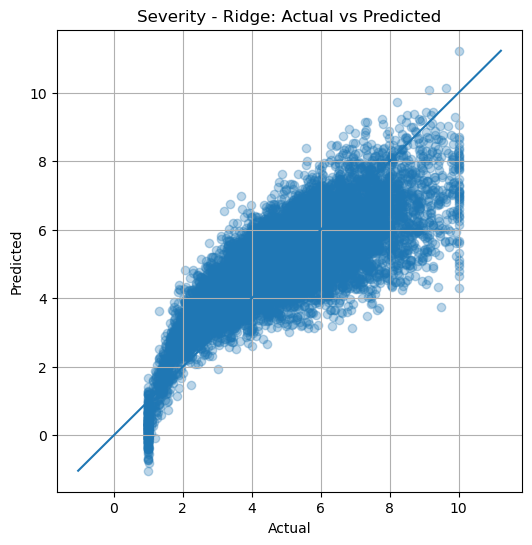

In [30]:
sev_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))  # Ridge helps with many one-hot columns
])

sev_ridge.fit(X_train, y_train_sev)
pred = sev_ridge.predict(X_test)
regression_report(y_test_sev, pred, "Severity - Ridge")
plot_pred_vs_actual(y_test_sev, pred, "Severity - Ridge: Actual vs Predicted")

The Ridge Regression model explains approximately 63% of the variance in disaster severity, indicating that the selected predictors capture meaningful linear relationships with severity outcomes. The MAE of about 0.94 suggests that, on average, severity predictions deviate by less than one unit from observed values. The close alignment between MAE and RMSE indicates stable errors with few extreme mispredictions. Overall, Ridge Regression provides a strong baseline but is limited in capturing nonlinear relationships.

### Random Forest (nonlinear, robust)


--- Severity - Random Forest ---
MAE : 0.9037
RMSE: 1.1737
R²  : 0.6349


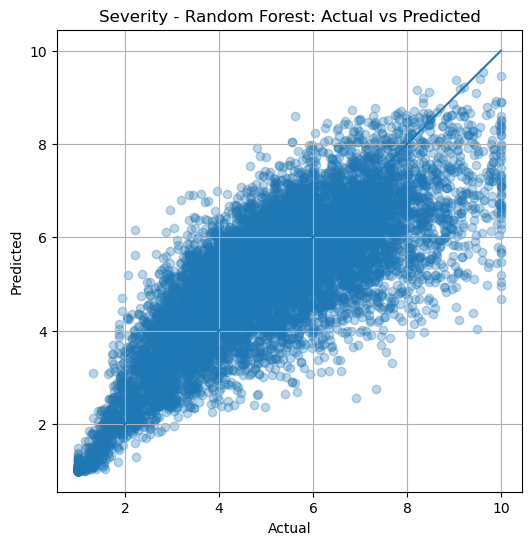

In [31]:
sev_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

sev_rf.fit(X_train, y_train_sev)
pred = sev_rf.predict(X_test)
regression_report(y_test_sev, pred, "Severity - Random Forest")
plot_pred_vs_actual(y_test_sev, pred, "Severity - Random Forest: Actual vs Predicted")

The Random Forest model shows modest improvement over the linear baseline, reducing MAE and increasing R² to approximately 0.63. This suggests that nonlinear interactions between predictors such as disaster type, geography, and response characteristics improve predictive accuracy. Error magnitudes remain stable, indicating consistent performance across severity levels. The results highlight the value of ensemble tree-based methods for modeling disaster severity.

### XGBoost 


--- Severity - XGBoost ---
MAE : 0.8958
RMSE: 1.1632
R²  : 0.6414


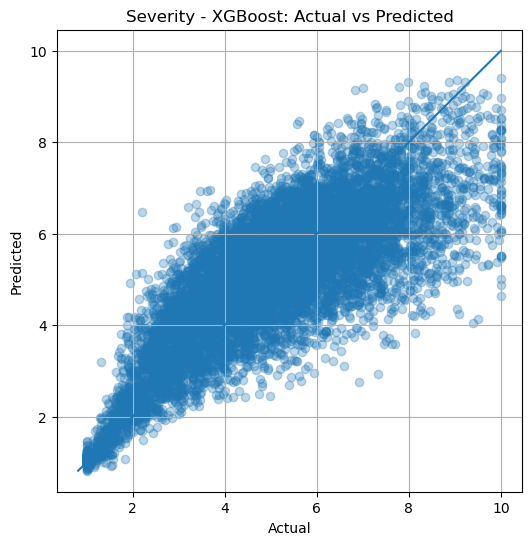

In [32]:
from xgboost import XGBRegressor

sev_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

sev_xgb.fit(X_train, y_train_sev)
pred = sev_xgb.predict(X_test)
regression_report(y_test_sev, pred, "Severity - XGBoost")
plot_pred_vs_actual(y_test_sev, pred, "Severity - XGBoost: Actual vs Predicted")

XGBoost achieves the best performance among the severity models, with the lowest MAE and highest R². This indicates improved explanatory power and more accurate predictions compared to both Ridge Regression and Random Forest. The similarity between MAE and RMSE suggests reliable performance without excessive influence from outliers. These results demonstrate XGBoost’s effectiveness in capturing complex, nonlinear relationships in disaster severity data.

## Economic Loss Model (target = log1p(economic_loss_usd))

In [33]:
# Economic loss is highly right-skewed.
# Use log1p() to compress extreme values and improve regression stability.
df["log_economic_loss"] = np.log1p(df["economic_loss_usd"])
y_loss = df["log_economic_loss"]

y_train_loss = y_loss.loc[X_train.index]
y_test_loss = y_loss.loc[X_test.index]

### Ridge


--- Loss(log) - Ridge ---
MAE : 0.5477
RMSE: 0.7919
R²  : 0.2066


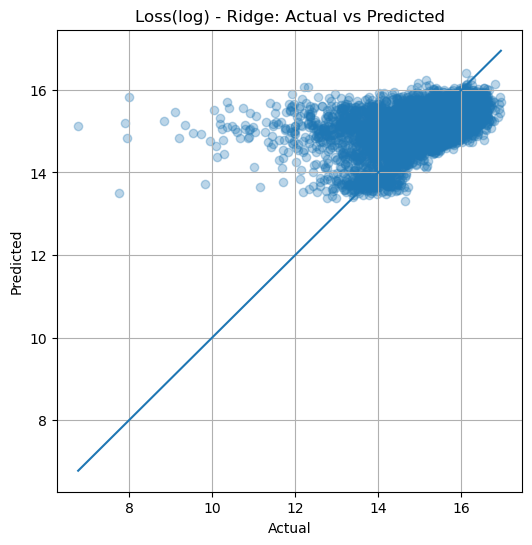

In [34]:
loss_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

loss_ridge.fit(X_train, y_train_loss)
pred_log = loss_ridge.predict(X_test)
regression_report(y_test_loss, pred_log, "Loss(log) - Ridge")
plot_pred_vs_actual(y_test_loss, pred_log, "Loss(log) - Ridge: Actual vs Predicted")

The Ridge Regression model shows limited explanatory power for economic loss, with an R² of approximately 0.21. While the MAE on the log scale indicates moderate average error, a large portion of variance in economic losses remains unexplained. This suggests that economic outcomes are influenced by additional structural and contextual factors not captured in the dataset.

### Random Forest


--- Loss(log) - Random Forest ---
MAE : 0.5630
RMSE: 0.8020
R²  : 0.1861


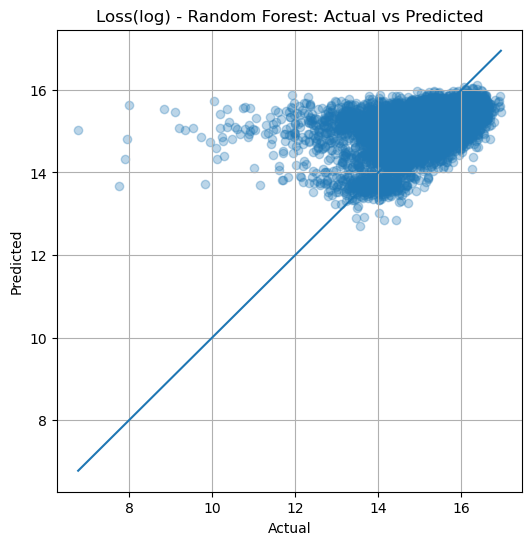

In [35]:
loss_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

loss_rf.fit(X_train, y_train_loss)
pred_log = loss_rf.predict(X_test)
regression_report(y_test_loss, pred_log, "Loss(log) - Random Forest")
plot_pred_vs_actual(y_test_loss, pred_log, "Loss(log) - Random Forest: Actual vs Predicted")

The Random Forest model performs similarly to Ridge Regression for economic loss prediction, with no substantial improvement in R². This indicates that introducing nonlinear structure does not significantly enhance predictability given the available features. Economic loss appears to be inherently more volatile and difficult to predict than disaster severity.

### XGBoost


--- Loss(log) - XGBoost ---
MAE : 0.5595
RMSE: 0.8031
R²  : 0.1838


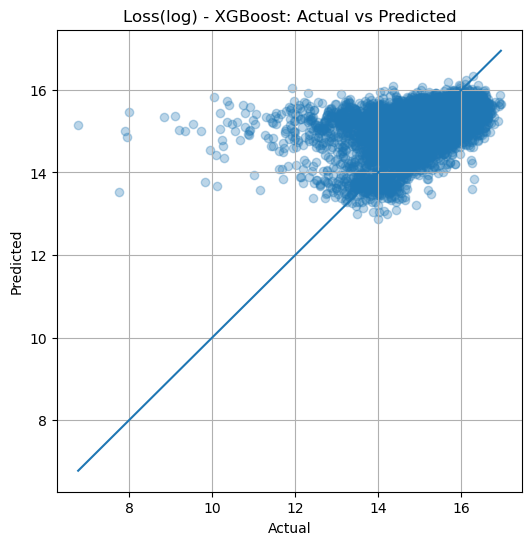

In [36]:
loss_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

loss_xgb.fit(X_train, y_train_loss)
pred_log = loss_xgb.predict(X_test)
regression_report(y_test_loss, pred_log, "Loss(log) - XGBoost")
plot_pred_vs_actual(y_test_loss, pred_log, "Loss(log) - XGBoost: Actual vs Predicted")

XGBoost yields performance comparable to Random Forest for economic loss prediction, suggesting diminishing returns from additional model complexity. Despite its ability to model nonlinear interactions, predictive accuracy remains constrained by high variability and unobserved drivers of economic loss.

### Convert log predictions back to USD

In [37]:
# Back-transform to USD so errors are in dollars (what stakeholders understand)
pred_usd = np.expm1(pred_log)
true_usd = np.expm1(y_test_loss)

print("\n--- Economic Loss in USD (Back-transformed) ---")
print("MAE ($):", mean_absolute_error(true_usd, pred_usd))
print("RMSE ($):", np.sqrt(mean_squared_error(true_usd, pred_usd)))


--- Economic Loss in USD (Back-transformed) ---
MAE ($): 2267228.955515875
RMSE ($): 3073928.910631294


After converting predictions back to U.S. dollars, the average absolute prediction error is approximately $2.27 million. While this error magnitude is substantial, it is consistent with the highly skewed distribution of disaster-related economic losses, where a small number of catastrophic events dominate total costs. These results underscore the challenges of predicting absolute economic loss values and reinforce the importance of interpreting predictions as approximate estimates rather than precise forecasts.

### Feature Importance (Random Forest and XGBoost)

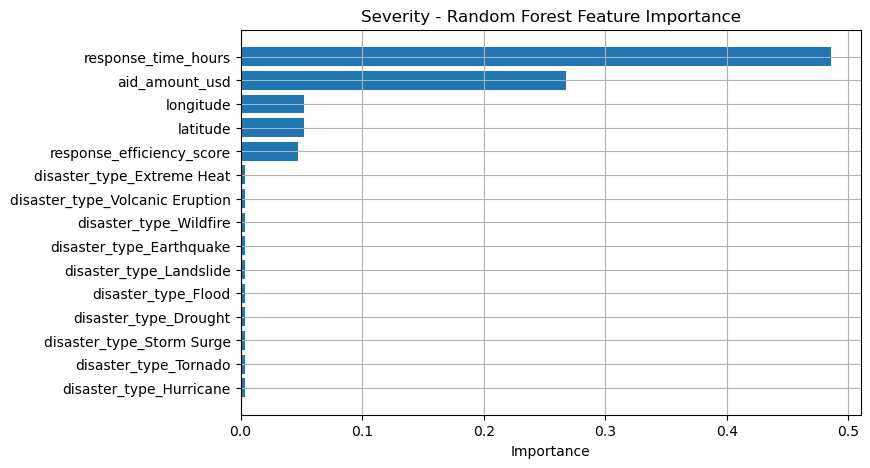

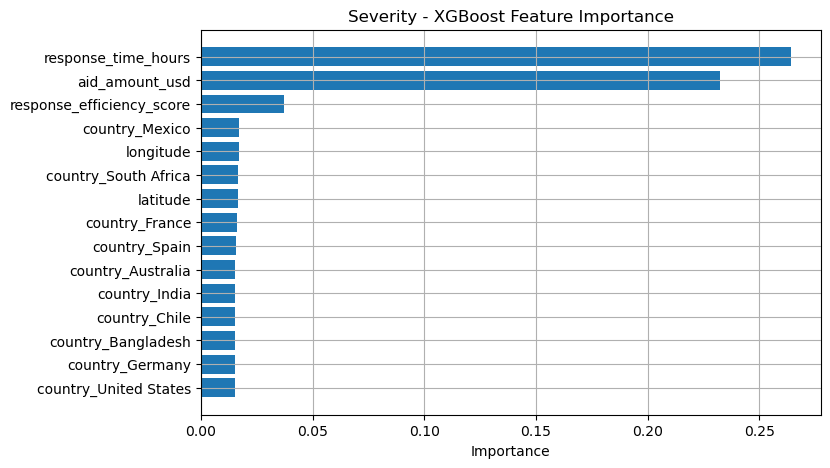

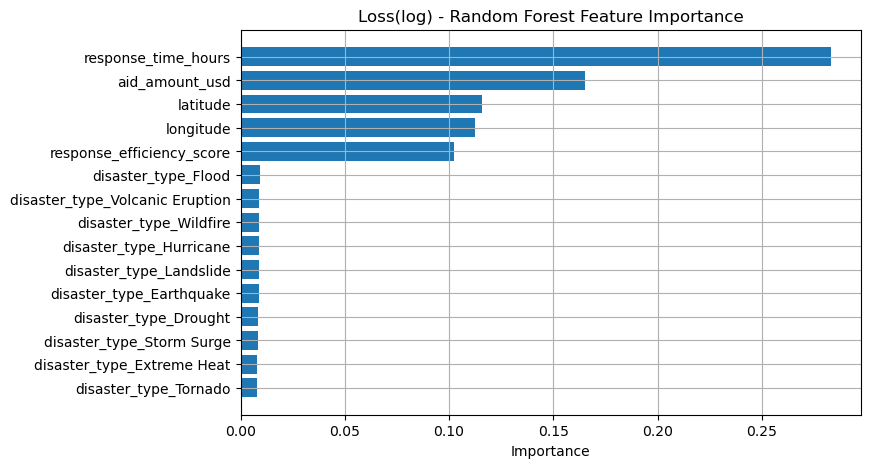

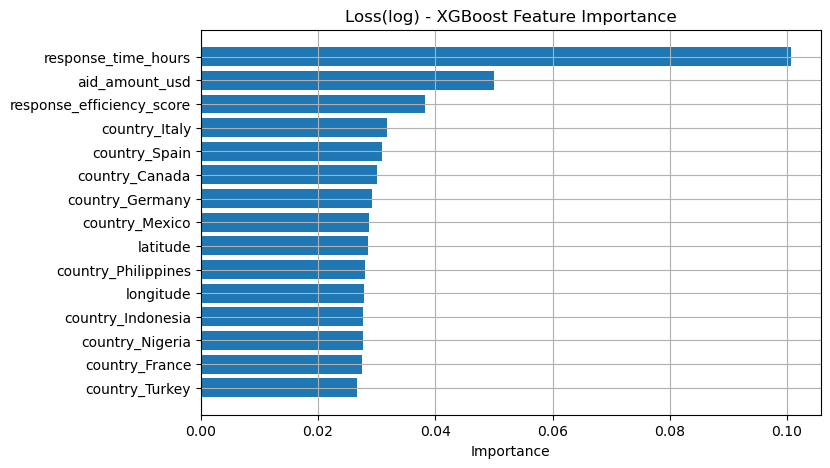

In [39]:
# In order to get column names due to OneHotEncoder

def get_feature_names(preprocessor, cat_features, num_features):
    """
    Builds the full feature name list after preprocessing,
    so feature importances map to readable labels.
    """
    ohe = preprocessor.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(cat_features)
    return np.concatenate([cat_names, np.array(num_features)])

def plot_top_importances(pipeline, title, top_n=15):
    """
    Plots top N feature importances for tree models (RF/XGB).
    """
    pre = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    feature_names = get_feature_names(pre, cat_features, num_features)
    importances = model.feature_importances_

    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(8,5))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()

# Example: run after fitting
plot_top_importances(sev_rf, "Severity - Random Forest Feature Importance")
plot_top_importances(sev_xgb, "Severity - XGBoost Feature Importance")
plot_top_importances(loss_rf, "Loss(log) - Random Forest Feature Importance")
plot_top_importances(loss_xgb, "Loss(log) - XGBoost Feature Importance")

Feature importance analysis from the tree-based models indicates that response-related variables are the strongest drivers of disaster outcomes. Across both severity and economic loss models, response time consistently emerged as the most influential predictor, followed by aid amount and response efficiency score. These results suggest that delays in response and limitations in operational capacity substantially increase both disaster severity and associated economic losses.

Geographic variables, including latitude, longitude, and country, contributed moderate predictive value, reflecting regional differences in exposure, infrastructure, and institutional capacity. In contrast, disaster type exhibited lower relative importance once response and location factors were accounted for, indicating that disaster impacts are not determined solely by hazard classification but are strongly shaped by contextual and operational condition

Geographic variables, including latitude, longitude, and country, contributed moderate predictive value, reflecting regional differences in exposure, infrastructure, and institutional capacity. In contrast, disaster type exhibited lower relative importance once response and location factors were accounted for, indicating that disaster impacts are not determined solely by hazard classification but are strongly shaped by contextual and operational condition

In [40]:
# Create results table (Severity and Economic Loss)

results = pd.DataFrame({
    "Model": [
        "Severity - Ridge",
        "Severity - Random Forest",
        "Severity - XGBoost",
        "Economic Loss (log) - Ridge",
        "Economic Loss (log) - Random Forest",
        "Economic Loss (log) - XGBoost"
    ],
    "MAE": [
        0.9372,
        0.9037,
        0.8958,
        0.5477,
        0.5630,
        0.5595
    ],
    "RMSE": [
        1.1873,
        1.1737,
        1.1632,
        0.7919,
        0.8020,
        0.8031
    ],
    "R²": [
        0.6264,
        0.6349,
        0.6414,
        0.2066,
        0.1861,
        0.1838
    ]
})

results

,Model,MAE,RMSE,R²
0,Severity - Ridge,0.9372,1.1873,0.6264
1,Severity - Random Forest,0.9037,1.1737,0.6349
2,Severity - XGBoost,0.8958,1.1632,0.6414
3,Economic Loss (log) - Ridge,0.5477,0.7919,0.2066
4,Economic Loss (log) - Random Forest,0.5630,0.8020,0.1861
5,Economic Loss (log) - XGBoost,0.5595,0.8031,0.1838


In [41]:
# highlight best performing model per target
def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_best]

results.style.apply(highlight_best, subset=["R²"]) \
              .format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R²": "{:.3f}"})

,Model,MAE,RMSE,R²
0,Severity - Ridge,0.937,1.187,0.626
1,Severity - Random Forest,0.904,1.174,0.635
2,Severity - XGBoost,0.896,1.163,0.641
3,Economic Loss (log) - Ridge,0.548,0.792,0.207
4,Economic Loss (log) - Random Forest,0.563,0.802,0.186
5,Economic Loss (log) - XGBoost,0.559,0.803,0.184


In [43]:
def plot_importances_4panel(
    sev_rf, sev_xgb, loss_rf, loss_xgb,
    cat_features, num_features,
    top_n=12
):
    """
    Displays feature importance comparisons in a 2x2 grid
    without modifying existing plotting functions.
    """

    pipelines = [sev_rf, sev_xgb, loss_rf, loss_xgb]
    titles = [
        "Severity – Random Forest",
        "Severity – XGBoost",
        "Economic Loss (log) – Random Forest",
        "Economic Loss (log) – XGBoost"
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, pipe, title in zip(axes, pipelines, titles):
        pre = pipe.named_steps["preprocessor"]
        model = pipe.named_steps["model"]

        feature_names = get_feature_names(pre, cat_features, num_features)
        importances = model.feature_importances_

        imp_df = (
            pd.DataFrame({"feature": feature_names, "importance": importances})
            .sort_values("importance", ascending=False)
            .head(top_n)
        )

        ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
        ax.set_title(title)
        ax.set_xlabel("Importance")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

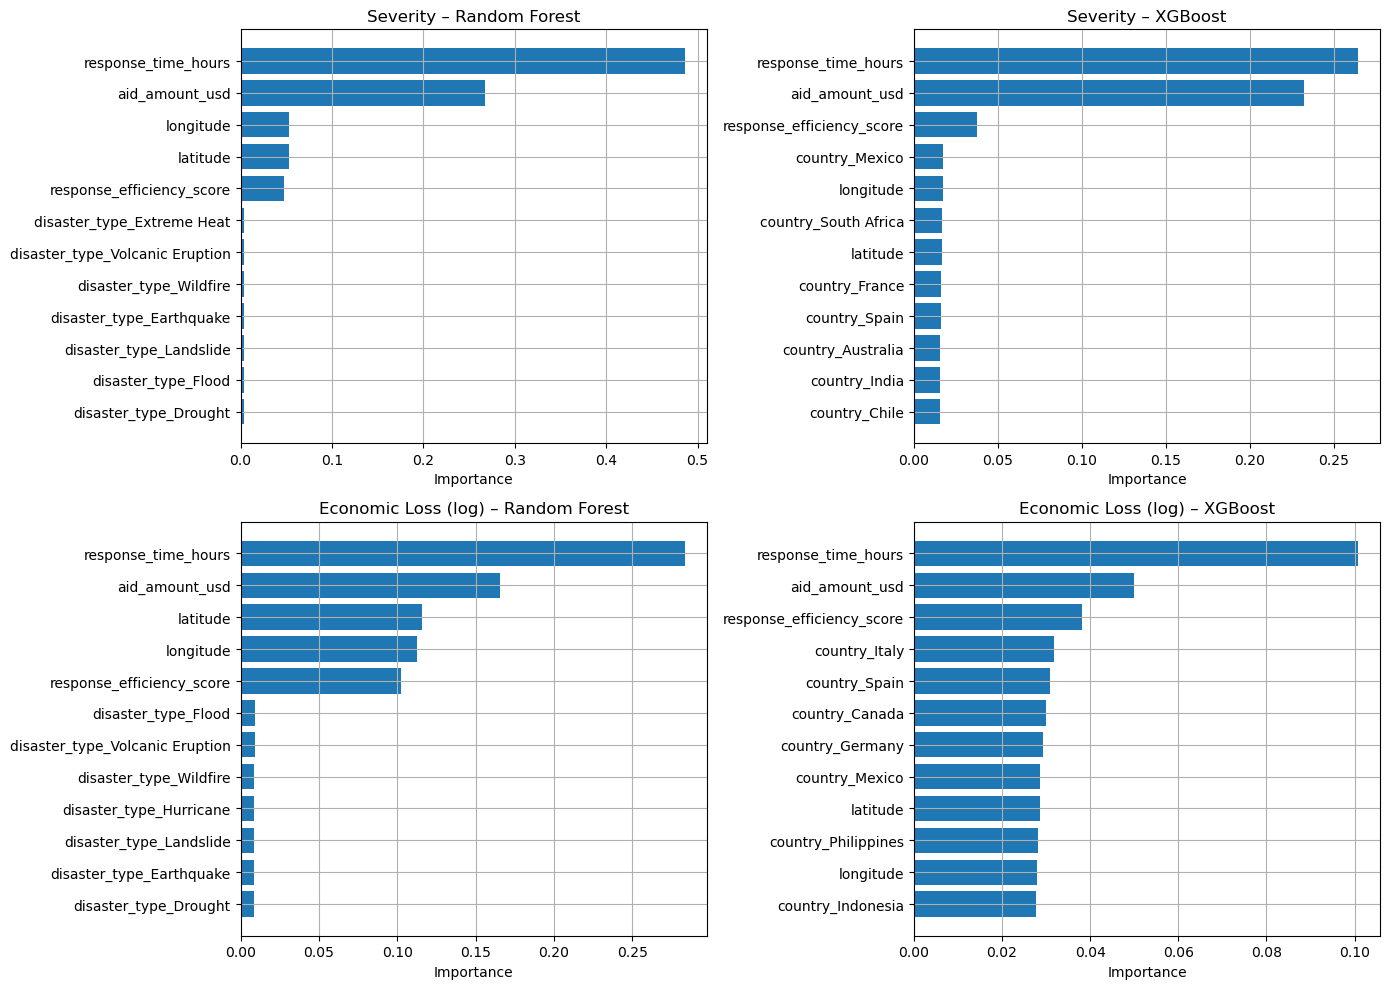

In [44]:
plot_importances_4panel(
    sev_rf, sev_xgb, loss_rf, loss_xgb,
    cat_features, num_features
)